In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Verificar instalación
print(f"PyTorch version: {torch.__version__}")
print(f"GPU disponible: {torch.cuda.is_available()}")
print("PyTorch listo.")


PyTorch version: 2.12.1+cpu
GPU disponible: False
PyTorch listo.


In [3]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score

# Recrear el dataset de mantenimiento
np.random.seed(42)
n_equipos = 100
datos = []

for equipo_id in range(n_equipos):
    vida_util = np.random.randint(100, 300)
    for ciclo in range(1, vida_util + 1):
        degradacion = ciclo / vida_util
        temperatura = 800 + 50 * degradacion + np.random.normal(0, 5)
        vibracion   = 0.3 + 0.7 * degradacion + np.random.normal(0, 0.05)
        presion     = 100 - 20 * degradacion + np.random.normal(0, 2)
        amperaje    = 50 + 30 * degradacion + np.random.normal(0, 3)
        rpm         = 3000 - 500 * degradacion + np.random.normal(0, 50)
        rul         = vida_util - ciclo
        falla       = 1 if rul <= 30 else 0
        datos.append([equipo_id, ciclo, temperatura, vibracion,
                     presion, amperaje, rpm, falla])

import pandas as pd
df = pd.DataFrame(datos, columns=[
    'equipo_id', 'ciclo', 'temperatura', 'vibracion',
    'presion', 'amperaje', 'rpm', 'falla_inminente'])

# Preparar datos
features = ['temperatura', 'vibracion', 'presion', 'amperaje', 'rpm', 'ciclo']
X = df[features].values
y = df['falla_inminente'].values

# Split temporal por equipo
train_mask = df['equipo_id'] < 80
X_train = X[train_mask]
X_test  = X[~train_mask]
y_train = y[train_mask]
y_test  = y[~train_mask]

# Escalar
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Convertir a tensores de PyTorch
X_train_t = torch.FloatTensor(X_train)
X_test_t  = torch.FloatTensor(X_test)
y_train_t = torch.FloatTensor(y_train)
y_test_t  = torch.FloatTensor(y_test)

print(f"Train: {X_train_t.shape}")
print(f"Test:  {X_test_t.shape}")
print("Datos listos para PyTorch")

Train: torch.Size([16570, 6])
Test:  torch.Size([4136, 6])
Datos listos para PyTorch


In [4]:
# Definir la arquitectura de la red neuronal
class RedMantenimiento(nn.Module):
    def __init__(self):
        super(RedMantenimiento, self).__init__()
        
        # Capas de la red
        self.red = nn.Sequential(
            nn.Linear(6, 32),      # entrada: 6 features → 32 neuronas
            nn.ReLU(),             # función de activación
            nn.Linear(32, 16),     # 32 → 16 neuronas
            nn.ReLU(),
            nn.Linear(16, 1),      # 16 → 1 salida (probabilidad de falla)
            nn.Sigmoid()           # convierte a probabilidad entre 0 y 1
        )
    
    def forward(self, x):
        return self.red(x).squeeze()

# Crear la red
modelo = RedMantenimiento()
print(modelo)
print(f"\nParámetros totales: {sum(p.numel() for p in modelo.parameters())}")

RedMantenimiento(
  (red): Sequential(
    (0): Linear(in_features=6, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

Parámetros totales: 769


Entrenando red neuronal...
Epoch  10/50 | Loss: 0.6713
Epoch  20/50 | Loss: 0.6199
Epoch  30/50 | Loss: 0.5690
Epoch  40/50 | Loss: 0.5177
Epoch  50/50 | Loss: 0.4641


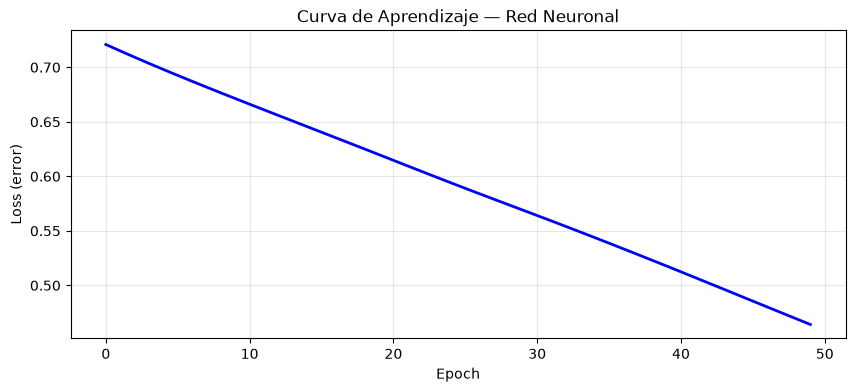

In [5]:
# Configurar entrenamiento
criterio   = nn.BCELoss()                          # función de costo para clasificación binaria
optimizador = torch.optim.Adam(modelo.parameters(), lr=0.001)  # el que ajusta los pesos

# Entrenamiento
epochs = 50
losses_train = []

print("Entrenando red neuronal...")
for epoch in range(epochs):
    modelo.train()
    
    # Forward pass — el modelo predice
    y_pred = modelo(X_train_t)
    loss   = criterio(y_pred, y_train_t)
    
    # Backward pass — calcular gradientes
    optimizador.zero_grad()
    loss.backward()
    optimizador.step()
    
    losses_train.append(loss.item())
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/50 | Loss: {loss.item():.4f}")

# Visualizar curva de aprendizaje
plt.figure(figsize=(10, 4))
plt.plot(losses_train, 'b-', linewidth=2)
plt.title('Curva de Aprendizaje — Red Neuronal')
plt.xlabel('Epoch')
plt.ylabel('Loss (error)')
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
# Evaluar en test
modelo.eval()
with torch.no_grad():
    y_prob_nn = modelo(X_test_t).numpy()
    y_pred_nn = (y_prob_nn > 0.5).astype(int)

accuracy_nn = accuracy_score(y_test, y_pred_nn)
auc_nn      = roc_auc_score(y_test, y_prob_nn)

print("=== RED NEURONAL vs RANDOM FOREST ===")
print(f"\n{'Métrica':15} {'Random Forest':>15} {'Red Neuronal':>15}")
print("-" * 48)
print(f"{'Accuracy':15} {'95.84%':>15} {accuracy_nn*100:>14.2f}%")
print(f"{'AUC-ROC':15} {'0.9900':>15} {auc_nn:>15.4f}")

=== RED NEURONAL vs RANDOM FOREST ===

Métrica           Random Forest    Red Neuronal
------------------------------------------------
Accuracy                 95.84%          94.68%
AUC-ROC                  0.9900          0.9842
